# 01 - EDA (lap time project)

Exploring lap time data before building anything. Trying to predict how
fast a driver's lap will be (in milliseconds), using stuff we'd know before
that lap happens - lap number, how long since their last pit stop, and
recent pace.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## load the csv files (using na_values since this dataset uses \\N for missing values)

In [2]:
lap_times = pd.read_csv("lap_times.csv", na_values="\\N")
races = pd.read_csv("races.csv", na_values="\\N")
results = pd.read_csv("results.csv", na_values="\\N")
drivers = pd.read_csv("drivers.csv", na_values="\\N")
constructors = pd.read_csv("constructors.csv", na_values="\\N")
pit_stops = pd.read_csv("pit_stops.csv", na_values="\\N")


In [3]:
lap_times.shape

(618766, 6)

In [4]:
lap_times.head()

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


In [5]:
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [7]:
drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [8]:
constructors.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [9]:
pit_stops.head()

,raceId,driverId,stop,lap,time,duration,milliseconds
0,258,100,1,1,14:01:34,49.111,49111.0
1,258,79,1,17,14:20:46,28.482,28482.0
2,258,57,1,18,14:22:35,43.745,43745.0
3,258,71,1,18,14:23:00,21.992,21992.0
4,258,105,1,19,14:24:39,27.693,27693.0


this is one row per driver per lap, milliseconds is the lap time - this is going to be our target

In [10]:
lap_times.isnull().sum()

raceId          0
driverId        0
lap             0
position        0
time            0
milliseconds    0
dtype: int64

## merge in race info (year, circuit) and constructor info

In [11]:
df = lap_times.merge(races[['raceId', 'year', 'round', 'circuitId']], on='raceId')

# results.csv tells us which constructor (team) each driver was racing for in each race
df = df.merge(results[['raceId', 'driverId', 'constructorId']], on=['raceId', 'driverId'])

df.shape


(589081, 10)

In [12]:
df.head()

,raceId,driverId,lap,position,time,milliseconds,year,round,circuitId,constructorId
0,841,20,1,1,1:38.109,98109,2011,1,1,9
1,841,20,2,1,1:33.006,93006,2011,1,1,9
2,841,20,3,1,1:32.713,92713,2011,1,1,9
3,841,20,4,1,1:32.803,92803,2011,1,1,9
4,841,20,5,1,1:32.342,92342,2011,1,1,9


## look at the target (lap time in milliseconds)

In [13]:
df['milliseconds'].describe()

count    5.890810e+05
mean     9.579945e+04
std      7.639973e+04
min      5.540400e+04
25%      8.204100e+04
50%      9.060800e+04
75%      1.019300e+05
max      7.507547e+06
Name: milliseconds, dtype: float64

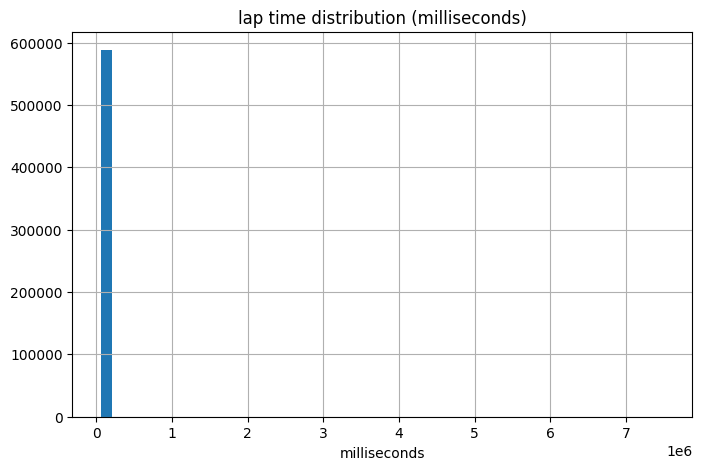

In [ ]:
plt.figure(figsize=(8,5))
df['milliseconds'].hist(bins=50)
plt.title("lap time distribution (milliseconds)")
plt.xlabel("milliseconds")
plt.show()


that long tail on the right is a red flag (pun intended) - those are
laps that were WAY slower than normal. probably safety car laps, laps
where someone crashed, pit laps, or red flag laps. this dataset doesn't
tell us which laps those are directly, so I'll need to filter obvious
outliers out later since they'd confuse the model.

## does lap number affect lap time? (fuel load gets lighter as the race goes on)

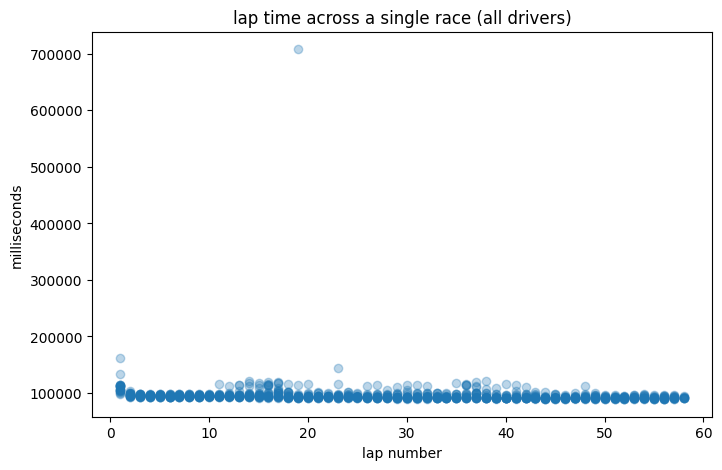

In [14]:
sample_race = df[df['raceId'] == df['raceId'].iloc[0]]
plt.figure(figsize=(8,5))
plt.scatter(sample_race['lap'], sample_race['milliseconds'], alpha=0.3)
plt.xlabel('lap number')
plt.ylabel('milliseconds')
plt.title('lap time across a single race (all drivers)')
plt.show()


you can kind of see it trend down a bit as the race goes on (car gets
lighter as fuel burns off) but there's a lot of noise - pit stops and
traffic mess with individual laps a lot.

## a heads up on data limitations

this dataset does NOT have tyre compound (soft/medium/hard) or weather
info. those are honestly two of the biggest things that affect real lap
times, but Ergast (where this data comes from) just doesn't track them.

so this project is going to work with what's actually available:
- lap number (proxy for fuel load)
- laps since the last pit stop (a rough proxy for tyre wear, not the real
  thing since we don't know the tyre compound)
- circuit (some tracks are just faster than others)
- driver / constructor recent pace

going to be upfront about this limitation in the README - if tyre and
weather data was available, this model would very likely do a lot better.
